# Project: Help doctors saving lives

In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve )
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             RocCurveDisplay)
from sklearn.metrics import roc_curve, auc

Check your dataset : check the number of rows and variable types, convert the variable if not right type, check for missing data and replace, check for duplicated rows.

In [297]:
df = pd.read_csv('Heart_Disease_Prediction.csv')
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [298]:
df.shape

(270, 14)

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [300]:
df.isna().sum() 

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [301]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [302]:
df["Heart Disease"].unique()

array(['Presence', 'Absence'], dtype=object)

In [303]:
df.duplicated().sum()

np.int64(0)

In [304]:
df_encoded = df.copy()
df_encoded['Heart Disease'] = df_encoded['Heart Disease'].map({ 'Presence': 1, 'Absence': 0 })


df_encoded.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


Descriptive analysis : for all variables, provide some descriptive analysis (Q1, Q3, mean, median, variance), histograms and distributions graphs. Provide an analysis based on this.

In [305]:
df_encoded.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


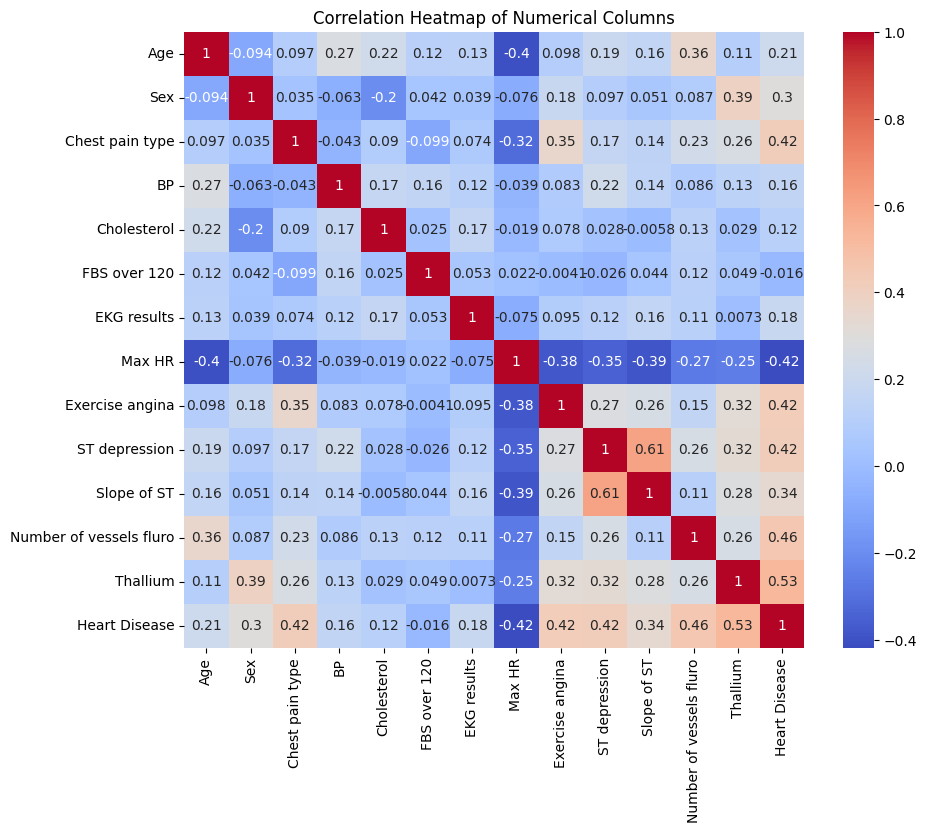

In [306]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()


Descriptive analysis : for all variables, provide some descriptive analysis (Q1, Q3, mean, median, variance), histograms and distributions graphs. Provide an analysis based on this.

In [307]:
num_cols = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
            'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
            'ST depression', 'Slope of ST', 'Number of vessels fluro',
            'Thallium', 'Heart Disease']


In [308]:
desc = df_encoded[num_cols].describe().T

# Renommer proprement
desc = desc.rename(columns={
    '25%': 'Q1',
    '50%': 'Median',
    '75%': 'Q3'
})

# Ajouter la variance
desc['Variance'] = df_encoded[num_cols].var()

print(desc[['mean', 'Median', 'Q1', 'Q3', 'Variance']])


                               mean  Median     Q1     Q3     Variance
Age                       54.433333    55.0   48.0   61.0    82.975093
Sex                        0.677778     1.0    0.0    1.0     0.219207
Chest pain type            3.174074     3.0    3.0    4.0     0.902671
BP                       131.344444   130.0  120.0  140.0   319.037051
Cholesterol              249.659259   245.0  213.0  280.0  2671.467107
FBS over 120               0.148148     0.0    0.0    0.0     0.126669
EKG results                1.022222     2.0    0.0    2.0     0.995787
Max HR                   149.677778   153.5  133.0  166.0   536.650434
Exercise angina            0.329630     0.0    0.0    1.0     0.221795
ST depression              1.050000     0.8    0.0    1.6     1.311506
Slope of ST                1.585185     2.0    1.0    2.0     0.377475
Number of vessels fluro    0.670370     0.0    0.0    1.0     0.890940
Thallium                   4.696296     3.0    3.0    7.0     3.766157
Heart 

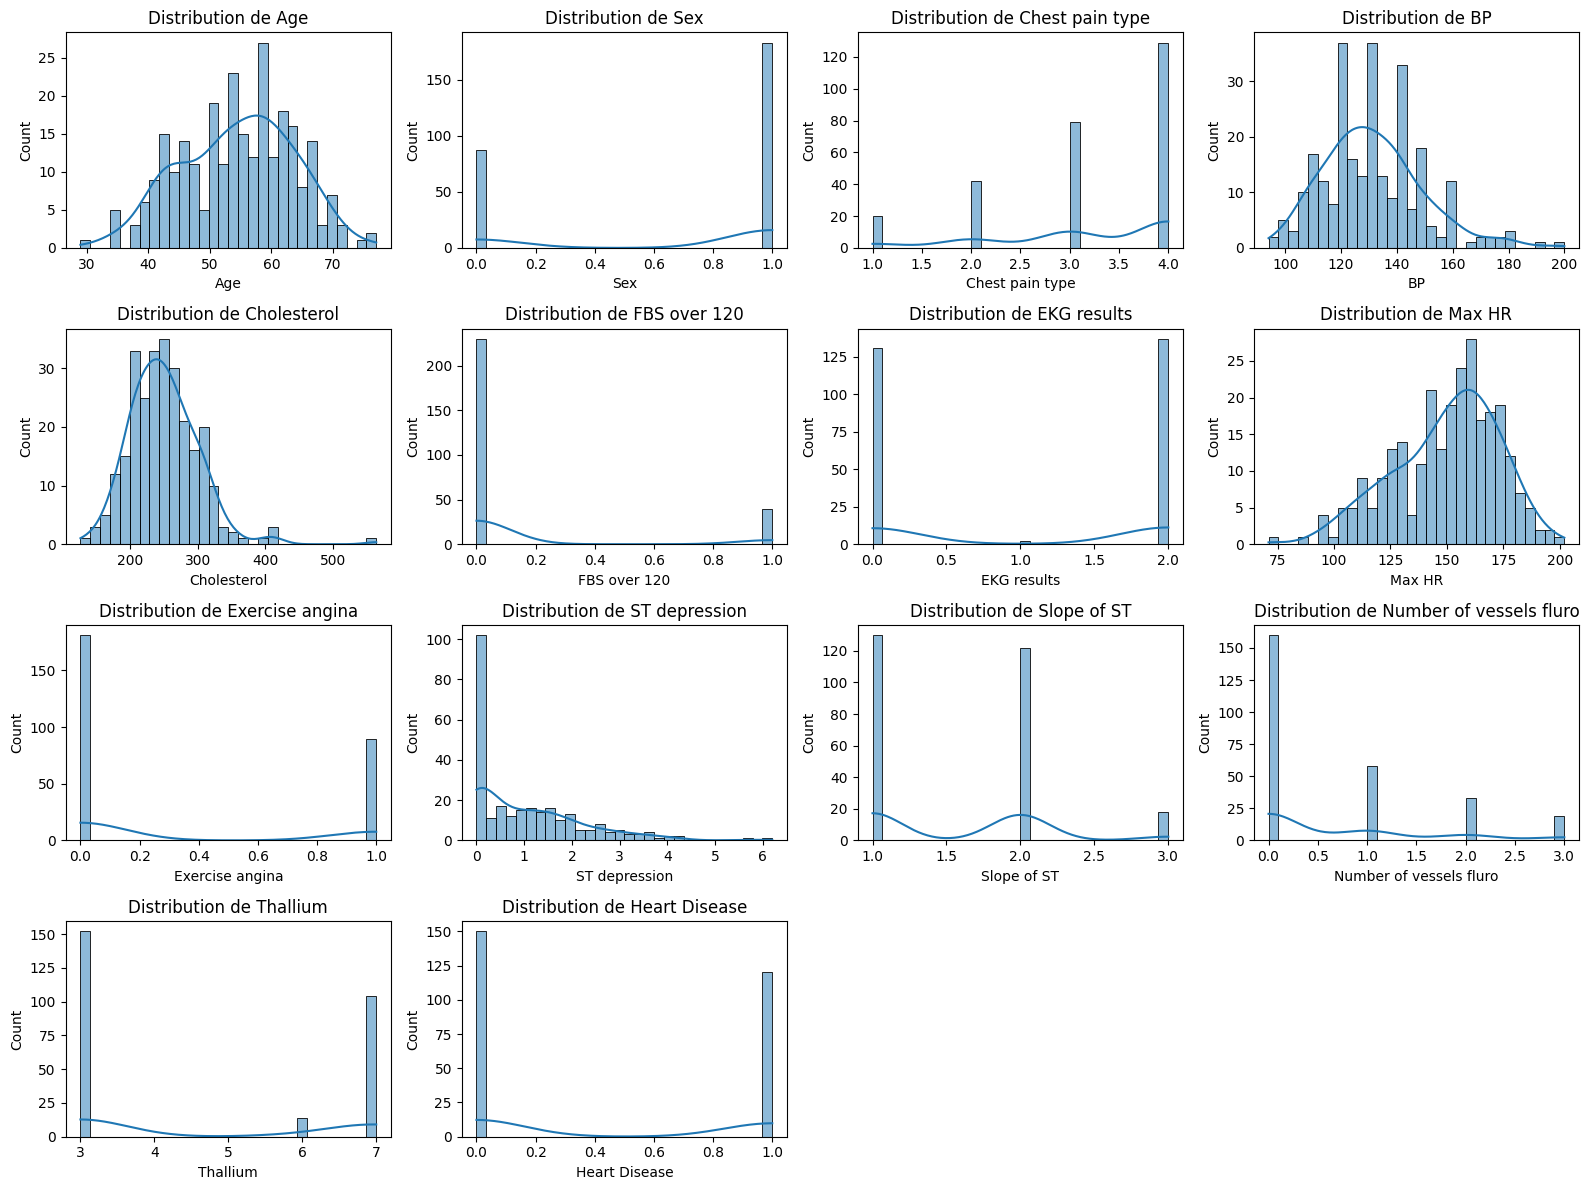

In [309]:
# Choisis le nombre de lignes et de colonnes
n_rows = 4
n_cols = 4

plt.figure(figsize=(n_cols*4, n_rows*3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_encoded[col], kde=True, bins=30)
    plt.title(f"Distribution de {col}")

plt.tight_layout()
plt.show()



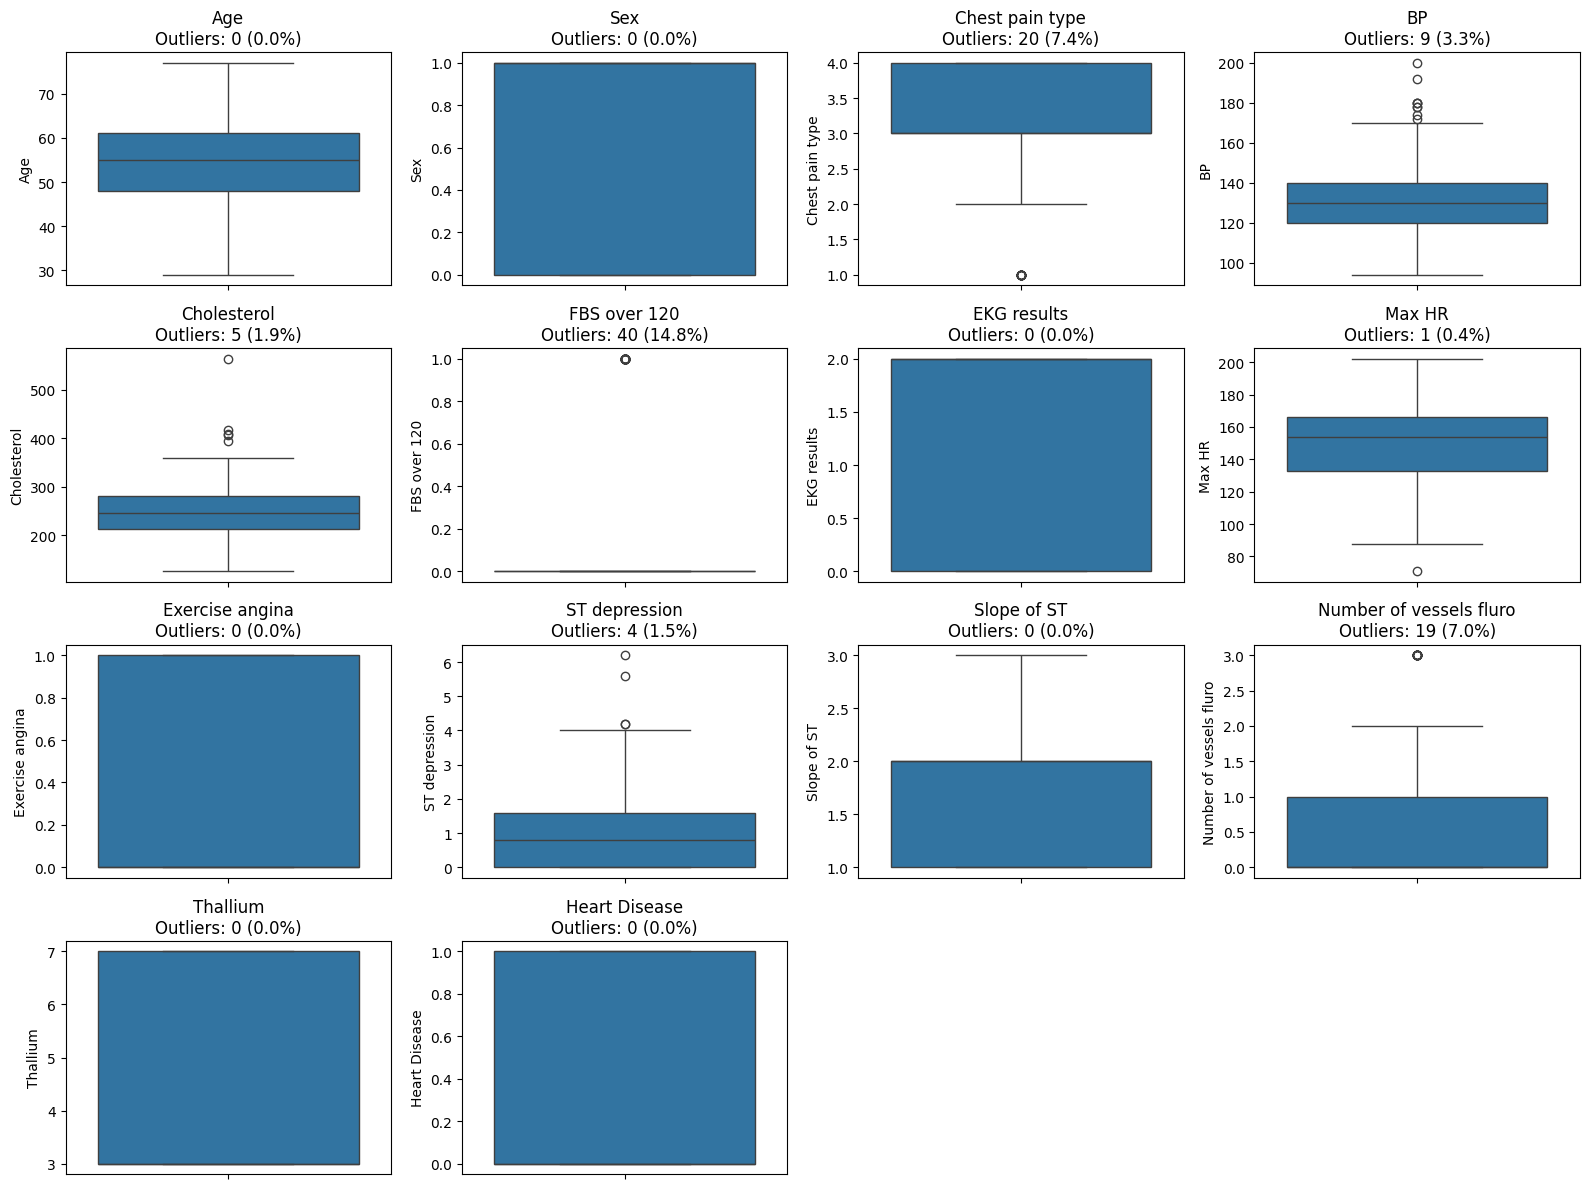

In [310]:
# Fonction pour compter les outliers selon la règle 1.5 * IQR
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), 100 * len(outliers) / len(series)

# Paramètres de la grille
n_rows = 4
n_cols = 4

plt.figure(figsize=(n_cols*4, n_rows*3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_encoded[col])
    
    # Calcul des outliers
    n_out, pct_out = count_outliers(df_encoded[col])
    
    # Titre avec nombre + pourcentage
    plt.title(f"{col}\nOutliers: {n_out} ({pct_out:.1f}%)")

plt.tight_layout()
plt.show()



In [311]:
def winsorize_iqr(df_encoded, cols):
    df_wins = df_encoded.copy()
    for col in cols:
        Q1 = df_wins[col].quantile(0.25)
        Q3 = df_wins[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_wins[col] = np.where(df_wins[col] < lower, lower,
                                np.where(df_wins[col] > upper, upper, df_wins[col]))
    return df_wins




In [312]:
df_wins = winsorize_iqr(df_encoded, num_cols)

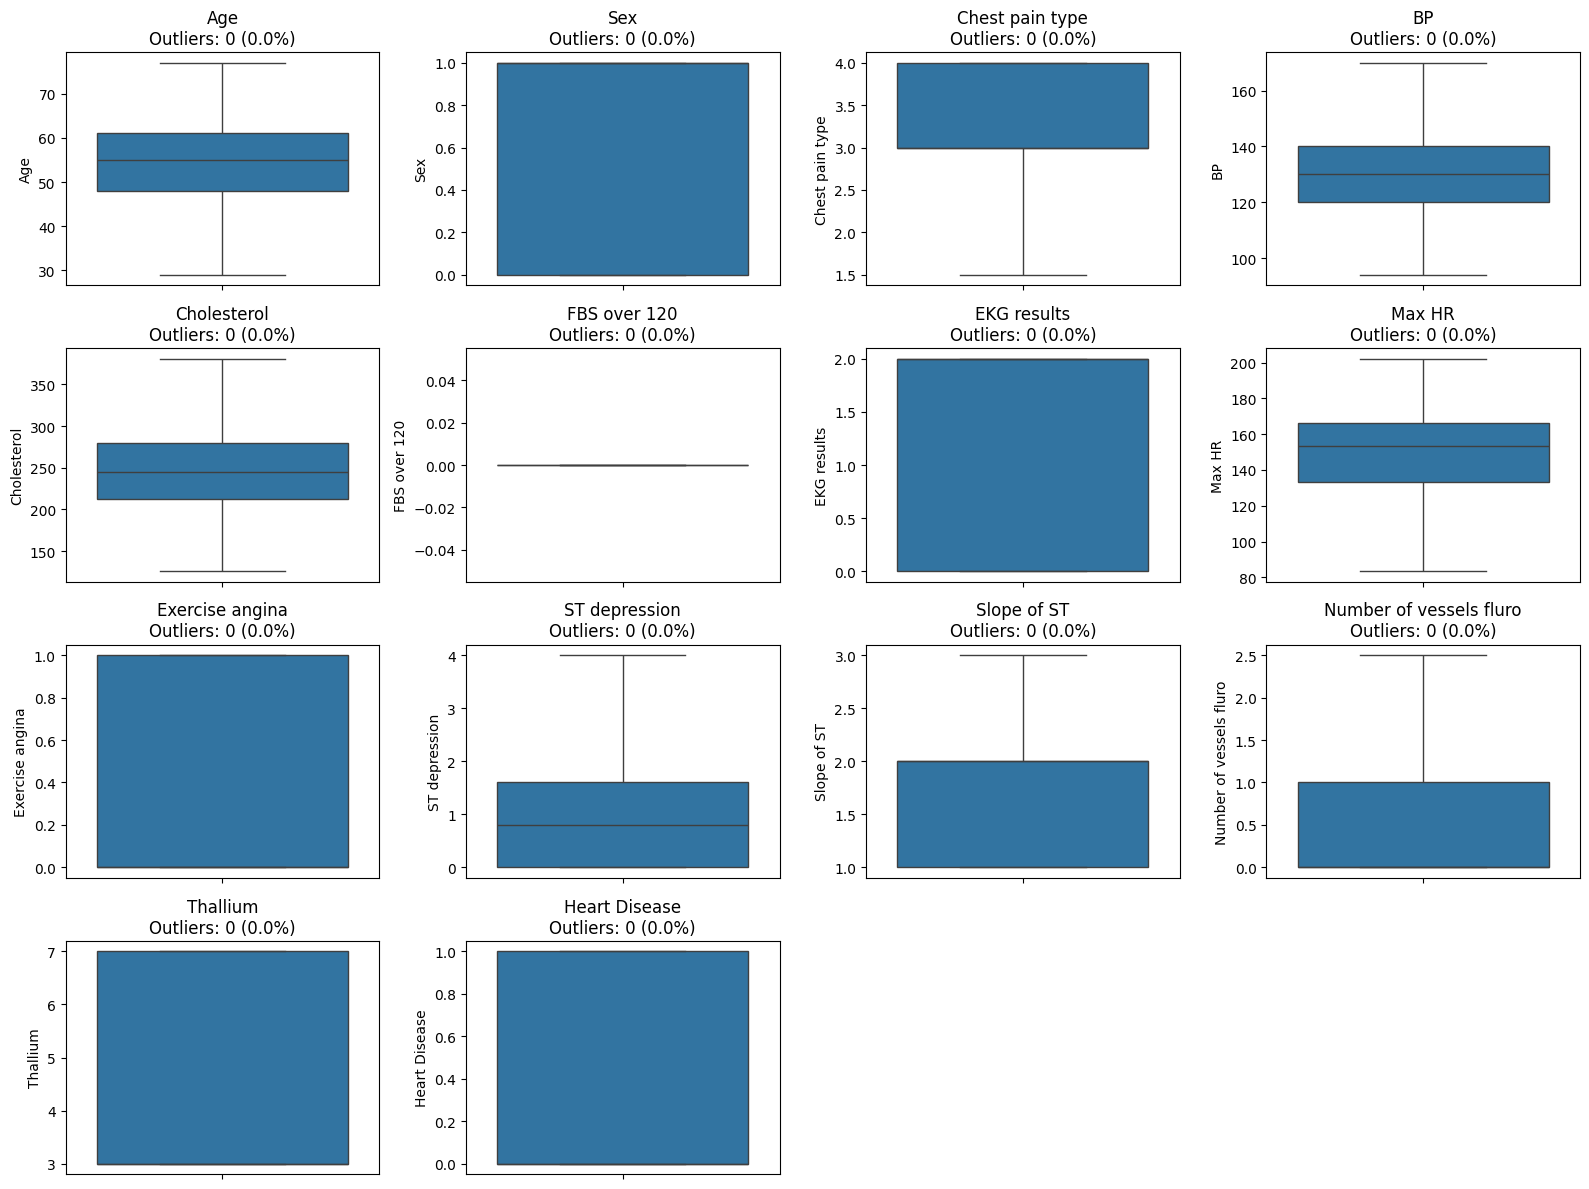

In [313]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), 100 * len(outliers) / len(series)

n_rows = 4
n_cols = 4

plt.figure(figsize=(n_cols*4, n_rows*3))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df_wins[col])
    
    n_out, pct_out = count_outliers(df_wins[col])
    plt.title(f"{col}\nOutliers: {n_out} ({pct_out:.1f}%)")

plt.tight_layout()
plt.show()


Multivariate analysis : build the correlation matrix and conclude. Provide an analysis based on this.

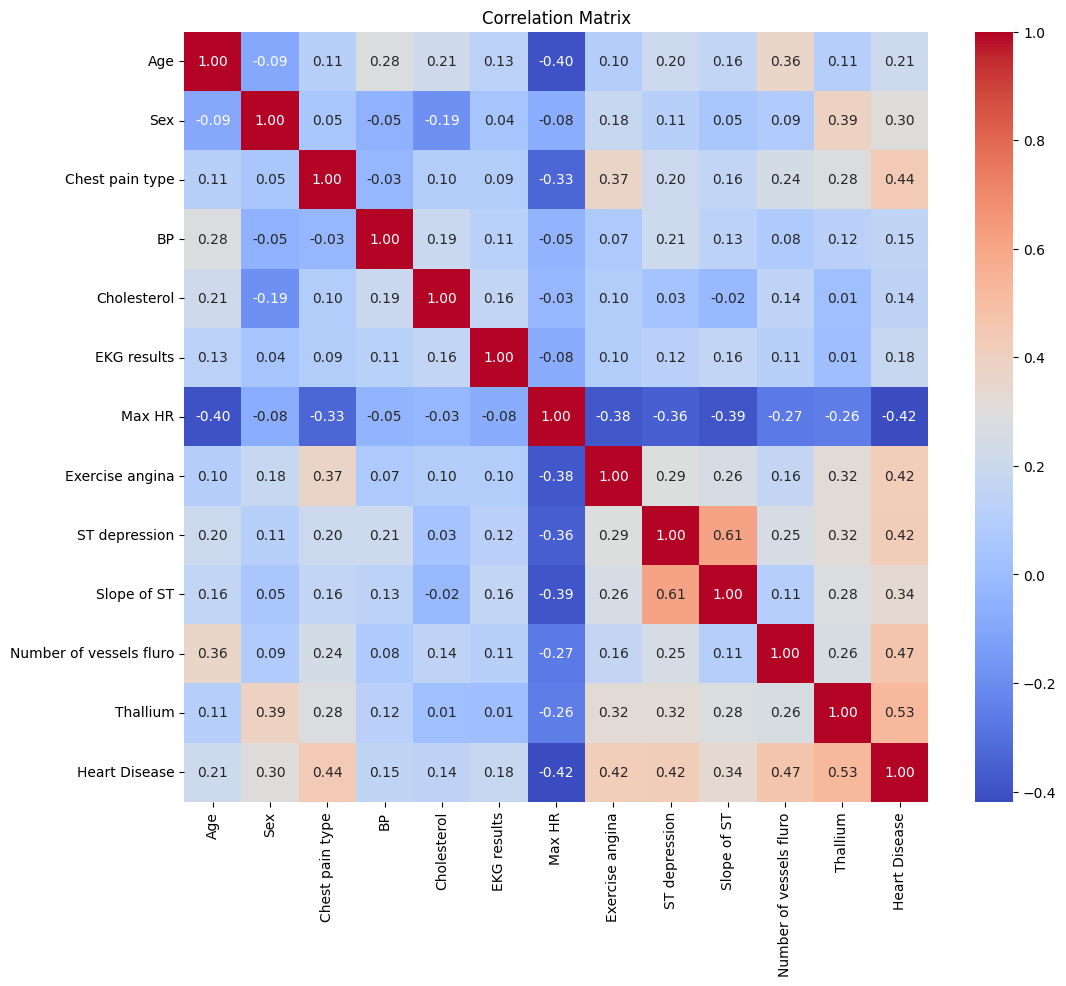

In [314]:
df_final = df_wins.copy()
df_final_cleaned = df_final.drop(columns=['FBS over 120']).copy()

num_cols_cleaned = [col for col in num_cols if col in df_final_cleaned.columns]


# Matrice de corrélation
corr_matrix = df_final_cleaned[num_cols_cleaned].corr()

# Affichage
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


After the outliers treatment,  we remark that the variable FBS over 120 no provide any information. So we decide to drop it in the dataset before next analysis.

**Bivariate Analysis**

In [315]:
# Variables truly categorical 
cat_vars = ['Sex', 'Chest pain type', 'EKG results',
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro',
            'Thallium']

# Variables continuous
cont_vars = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

target = 'Heart Disease'


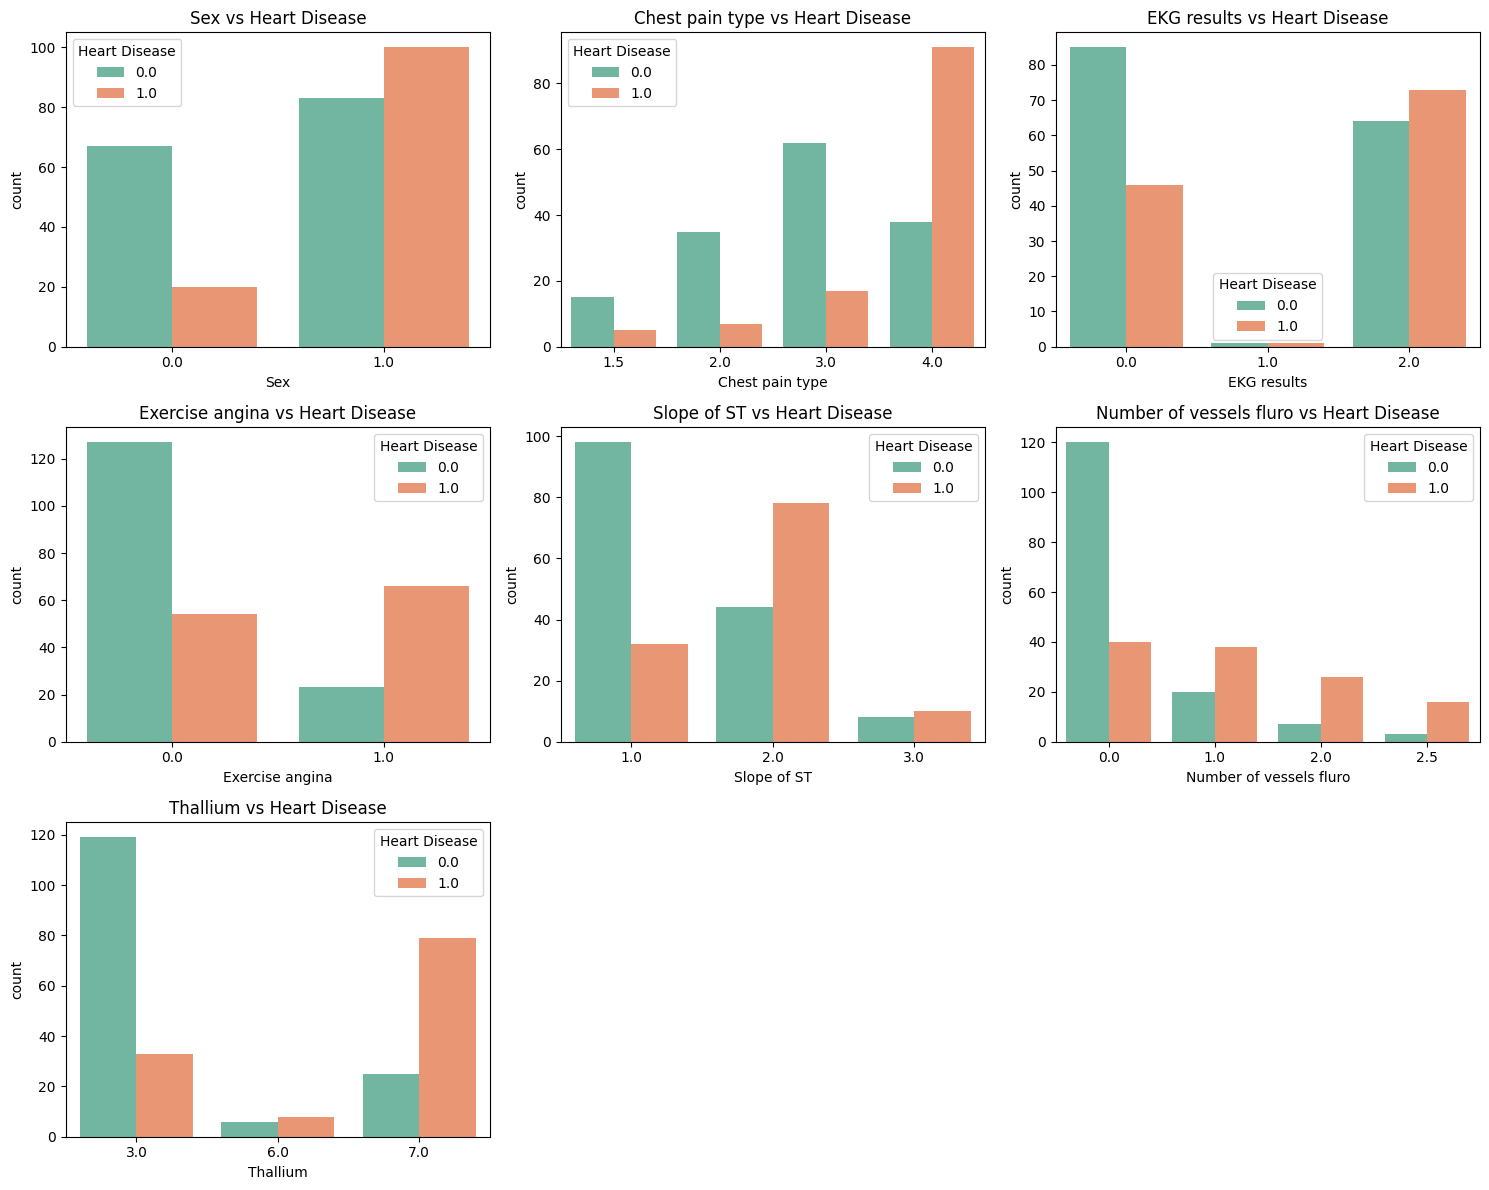

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11564\2333935900.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final_cleaned, x=target, y=var, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11564\2333935900.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final_cleaned, x=target, y=var, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11564\2333935900.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final_cleaned, x=target, y=var, ax=axes[i], palette='Set2'

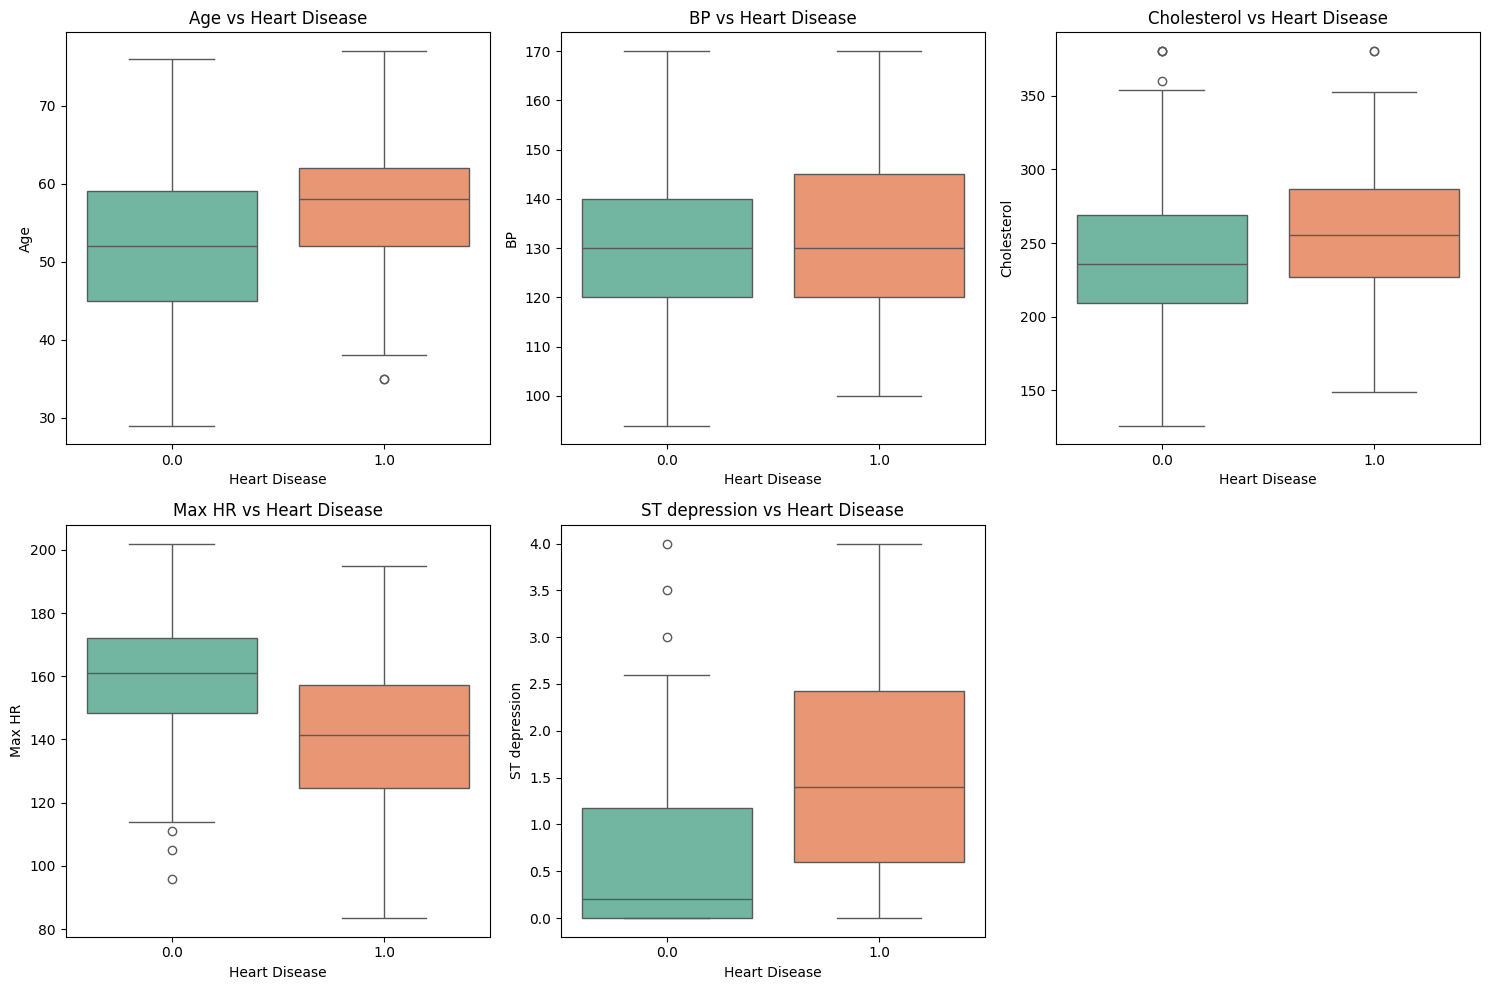

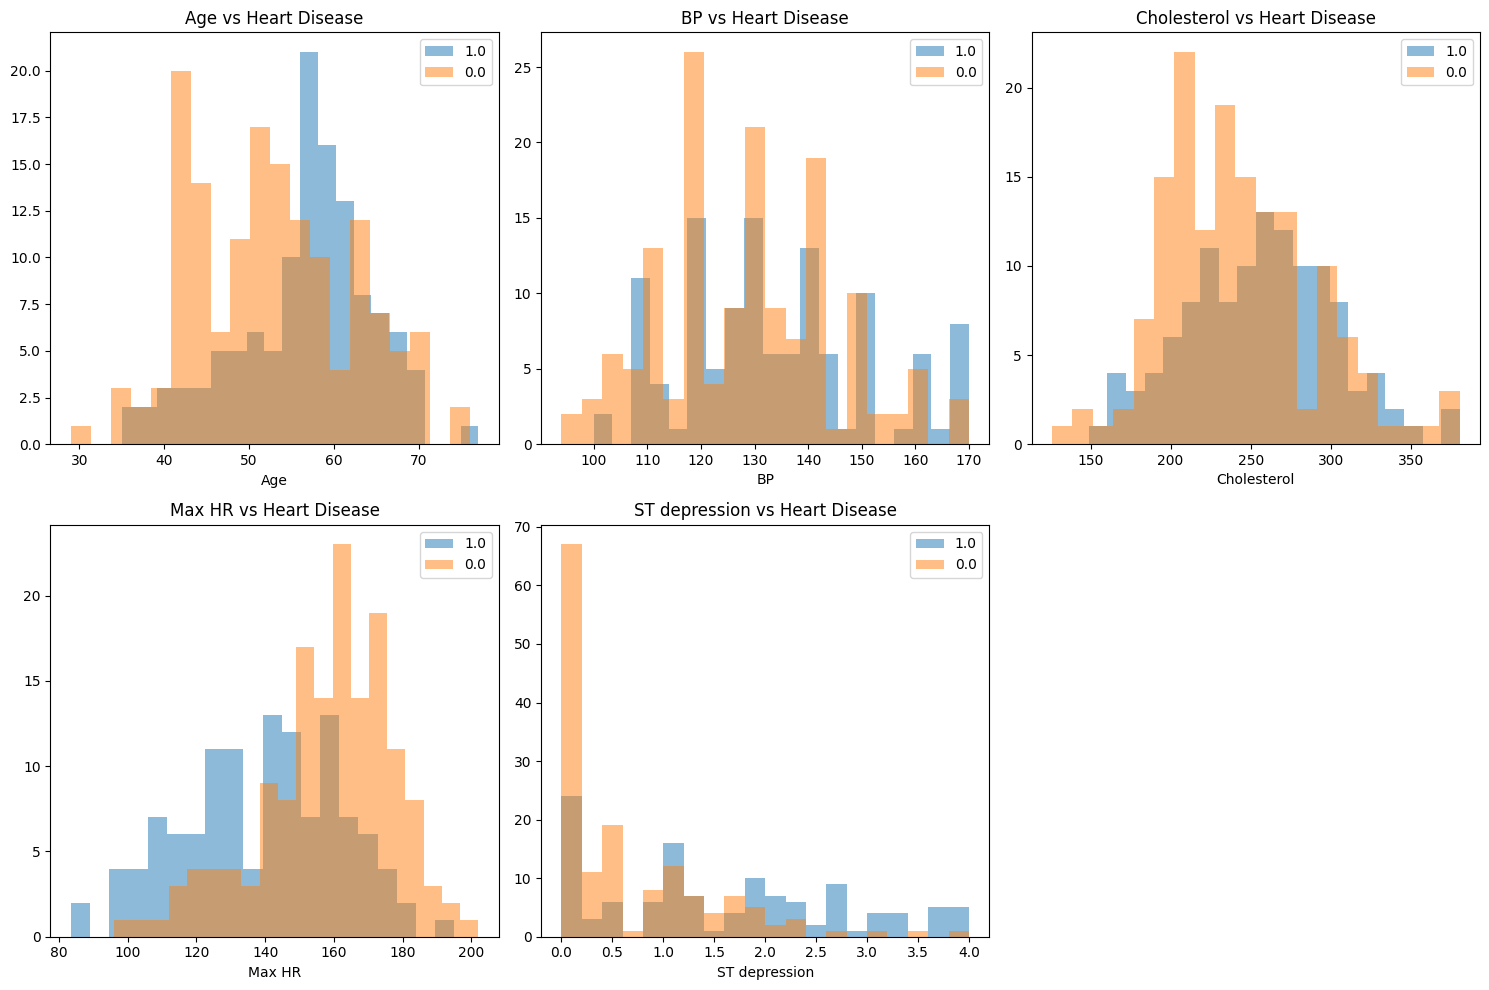

In [316]:
# === VARIABLES CATÉGORIELLES ===
# Graphiques en barres montrant la répartition par catégorie et Heart Disease

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    sns.countplot(data=df_final_cleaned, x=var, hue=target, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} vs {target}')
    axes[i].legend(title=target)

# Supprimer les axes vides
for j in range(len(cat_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
# === VARIABLES CONTINUES ===
# Boxplots ou histogrammes montrant la distribution par Heart Disease

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(cont_vars):
    sns.boxplot(data=df_final_cleaned, x=target, y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} vs {target}')

# Supprimer les axes vides
for j in range(len(cont_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(cont_vars):
    for label in df_final_cleaned[target].unique():
        subset = df_final_cleaned[df_final_cleaned[target] == label]
        axes[i].hist(subset[var], alpha=0.5, label=label, bins=20)
    axes[i].set_title(f'{var} vs {target}')
    axes[i].set_xlabel(var)
    axes[i].legend()

for j in range(len(cont_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [317]:
from scipy.stats import ttest_ind

def test_continuous(var):
    group0 = df_final_cleaned[df_final_cleaned[target] == 0][var]
    group1 = df_final_cleaned[df_final_cleaned[target] == 1][var]
    stat, p = ttest_ind(group0, group1, equal_var=False)
    return p


In [318]:
from scipy.stats import chi2_contingency

def test_categorical(var):
    table = pd.crosstab(df_final_cleaned[var], df_final_cleaned[target])
    chi2, p, dof, expected = chi2_contingency(table)
    return p

In [319]:
results = {}

# Continuous variables
for var in cont_vars:
    p = test_continuous(var)
    results[var] = p

# Categorical variables
for var in cat_vars:
    p = test_categorical(var)
    results[var] = p

# Display results sorted by significance
for var, p in sorted(results.items(), key=lambda x: x[1]):
    print(f"{var:25s}  p-value = {p:.5f}")

Thallium                   p-value = 0.00000
Chest pain type            p-value = 0.00000
Number of vessels fluro    p-value = 0.00000
Max HR                     p-value = 0.00000
ST depression              p-value = 0.00000
Exercise angina            p-value = 0.00000
Slope of ST                p-value = 0.00000
Sex                        p-value = 0.00000
Age                        p-value = 0.00035
EKG results                p-value = 0.01122
BP                         p-value = 0.01553
Cholesterol                p-value = 0.02114


You can interpret the results like this:

p < 0.05 → statistically significant
→ the variable is associated with Heart Disease
→ it is a candidate predictor

p ≥ 0.05 → no significant evidence
→ the variable is not associated with Heart Disease in your sample

**Model**

In [320]:
target = 'Heart Disease'

#  toutes les variables explicatives sauf "FBS over 120"
X = df_final_cleaned.drop(columns=[target])
y = df_final_cleaned[target]

In [321]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_vars),
        ("num", "passthrough", cont_vars),
    ],
    remainder="drop"
)


In [322]:
# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


In [323]:
# 6) Baseline decision tree (interpretable)
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,              # keep it interpretable
    min_samples_leaf=25,      # stabilize clinical rules
    class_weight="balanced",  # handle imbalance
    random_state=42
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", tree)])
pipe.fit(X_train, y_train)

# 7) Evaluate
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
specificity = tn / (tn + fp) if (tn + fp) else np.nan
auc = roc_auc_score(y_test, y_proba)

print("Confusion matrix:\n", cm)
print(f"Sensitivity (Recall +): {sensitivity:.3f}")
print(f"Specificity (Recall -): {specificity:.3f}")
print(f"AUC: {auc:.3f}\n")
print(classification_report(y_test, y_pred, digits=3))


Confusion matrix:
 [[32 13]
 [ 8 28]]
Sensitivity (Recall +): 0.778
Specificity (Recall -): 0.711
AUC: 0.830

              precision    recall  f1-score   support

         0.0      0.800     0.711     0.753        45
         1.0      0.683     0.778     0.727        36

    accuracy                          0.741        81
   macro avg      0.741     0.744     0.740        81
weighted avg      0.748     0.741     0.742        81



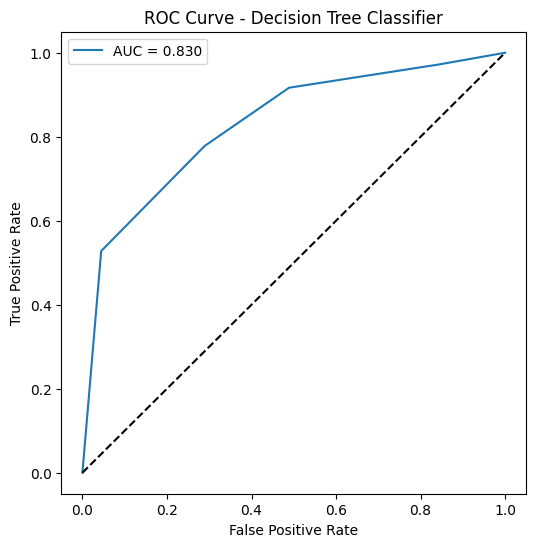

In [324]:
#from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree Classifier")
plt.legend()
plt.show()


In [325]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


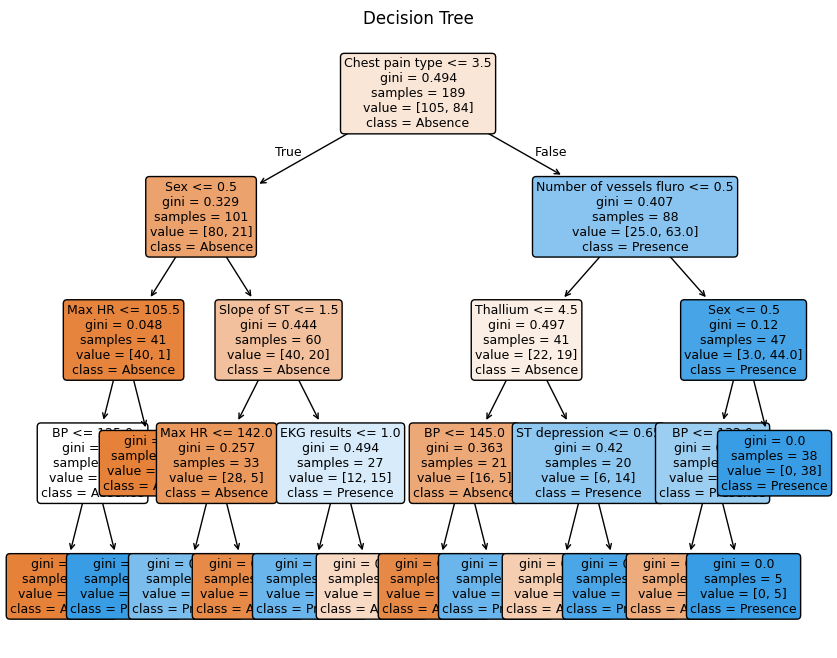

In [326]:
from sklearn.tree import plot_tree
features = X.columns
plt.figure(figsize=(10, 8))
plot_tree(tree, feature_names=features, class_names=['Absence', 'Presence'],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree")
plt.show()

In [327]:
print(export_text(tree, feature_names=features))

|--- Chest pain type <= 3.50
|   |--- Sex <= 0.50
|   |   |--- Max HR <= 105.50
|   |   |   |--- BP <= 125.00
|   |   |   |   |--- class: 0.0
|   |   |   |--- BP >  125.00
|   |   |   |   |--- class: 1.0
|   |   |--- Max HR >  105.50
|   |   |   |--- class: 0.0
|   |--- Sex >  0.50
|   |   |--- Slope of ST <= 1.50
|   |   |   |--- Max HR <= 142.00
|   |   |   |   |--- class: 1.0
|   |   |   |--- Max HR >  142.00
|   |   |   |   |--- class: 0.0
|   |   |--- Slope of ST >  1.50
|   |   |   |--- EKG results <= 1.00
|   |   |   |   |--- class: 1.0
|   |   |   |--- EKG results >  1.00
|   |   |   |   |--- class: 0.0
|--- Chest pain type >  3.50
|   |--- Number of vessels fluro <= 0.50
|   |   |--- Thallium <= 4.50
|   |   |   |--- BP <= 145.00
|   |   |   |   |--- class: 0.0
|   |   |   |--- BP >  145.00
|   |   |   |   |--- class: 1.0
|   |   |--- Thallium >  4.50
|   |   |   |--- ST depression <= 0.65
|   |   |   |   |--- class: 0.0
|   |   |   |--- ST depression >  0.65
|   |   |   |   |

In [328]:
importance = pd.DataFrame({'Variable': features, 'Importance': tree.feature_importances_})
importance = importance.sort_values('Importance', ascending=False)
print(importance)

                   Variable  Importance
2           Chest pain type    0.367093
10  Number of vessels fluro    0.148047
3                        BP    0.115616
1                       Sex    0.094780
9               Slope of ST    0.073333
11                 Thallium    0.066114
6                    Max HR    0.063706
8             ST depression    0.042602
5               EKG results    0.028708
0                       Age    0.000000
7           Exercise angina    0.000000
4               Cholesterol    0.000000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11564\2363835493.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


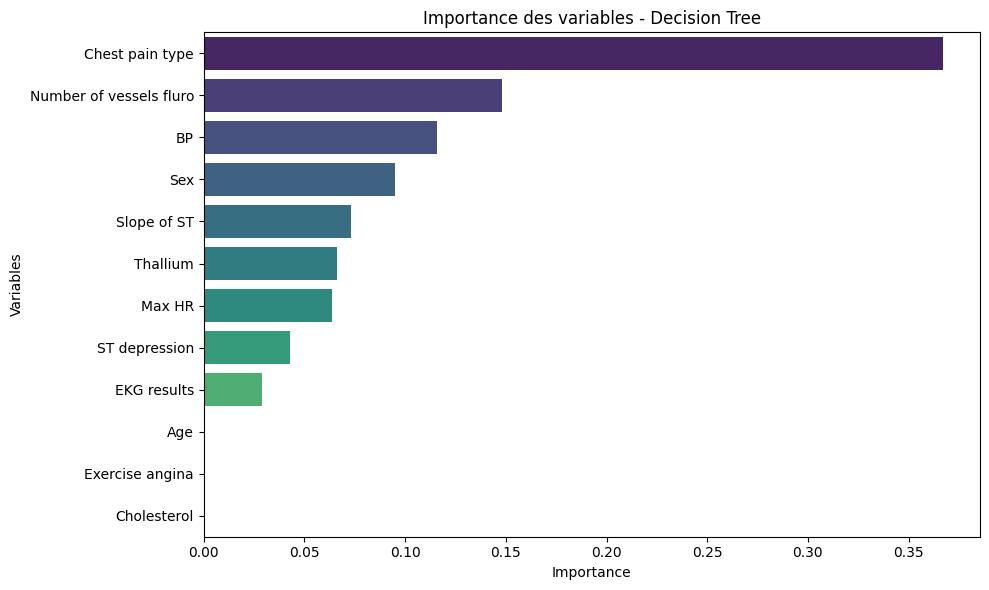

In [329]:
# DataFrame importance déjà créé
importance = pd.DataFrame({
    'Variable': features,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Variable',
    palette='viridis'
)

plt.title("Importance des variables - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()
